# SHAP-Driven Feature Optimization Experiment
## XAI → Cost Reduction for Mamba Wind Forecasting

**Two-phase pipeline:**

```
Phase 1: Train Mamba (all 22 features)
         → GradientExplainer → SHAP importance per site
         → Aggregate → Global feature ranking

Phase 2: Retrain Mamba with Top-K subsets [5, 8, 10, 12, 15, 22]
         → Record: RMSE / MAE / R² / train_time / latency
         → Find Pareto-optimal point (best accuracy/cost tradeoff)
```

**Claim this experiment supports:**  
> "SHAP-guided feature selection reduces input dimensionality by X%, cuts training time by Y%,  
> and maintains within Z% of full-feature RMSE."

**Sites:** A (Inland) · B (Coastal) · C (Complex Terrain) · D (Offshore)

## 0. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import subprocess
subprocess.run(['pip', 'install', 'shap', '-q'])

import os
DATA_DIR = '/content/drive/MyDrive/wind_forecast/'
SAVE_DIR = '/content/drive/MyDrive/wind_forecast/SHAP_Optimization/'
os.makedirs(SAVE_DIR, exist_ok=True)

Mounted at /content/drive


## 1. Imports & Config

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import gc, time, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import shap
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

SEED   = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

SEQ_LEN    = 12
HORIZONS   = [2, 4, 8]          # steps → 30 / 60 / 120 min
HOR_LABELS = ['30min', '60min', '120min']
BATCH_SIZE = 64
MAX_EPOCHS = 100
PATIENCE   = 10
N_SEEDS    = 3

ALL_FEATURES = [
    'temperature', 'pressure', 'hr_sin', 'hr_cos',
    'month_sin', 'month_cos', 'wind_sin', 'wind_cos',
    'ws_lag_1', 'ws_lag_4', 'ws_lag_24',
    'dewpoint_temp', 'cloud_cover', 'precipitation',
    'solar_radiation', 'u_wind', 'v_wind',
    'relative_humidity', 'air_density',
    'ws_rolling_mean_1h', 'ws_rolling_std_1h', 'ws_delta'
]  # 22 features


SUBSET_SIZES = [5, 8, 10, 12, 15, 22]

N_BG_SAMPLES   = 200
N_TEST_SAMPLES = 500

SITES = [
    {'code': 'A', 'name': 'Inland',          'file': 'Site A - Inland.csv'},
    {'code': 'B', 'name': 'Coastal',         'file': 'Site B - Coastal.csv'},
    {'code': 'C', 'name': 'Complex Terrain', 'file': 'Site C - Complex Terrain.csv'},
    {'code': 'D', 'name': 'Offshore',        'file': 'Site D - Offshore.csv'},
]
print(f'Features: {len(ALL_FEATURES)} | Subset sizes: {SUBSET_SIZES}')

Device: cuda
Features: 22 | Subset sizes: [5, 8, 10, 12, 15, 22]


## 2. Model & Data Utilities

In [ ]:
# ── Mamba model (identical to original, input_size is variable) ─────────────
class MambaBlock(nn.Module):
    def __init__(self, d_model, expand=2, d_conv=4, dropout=0.1):
        super().__init__()
        self.norm    = nn.LayerNorm(d_model)
        self.d_inner = expand * d_model
        self.in_proj = nn.Linear(d_model, self.d_inner * 2)
        self.conv1d  = nn.Conv1d(
            self.d_inner, self.d_inner,
            kernel_size=d_conv, padding=d_conv - 1, groups=self.d_inner
        )
        self.out_proj = nn.Linear(self.d_inner, d_model)
        self.dropout  = nn.Dropout(dropout)

    def forward(self, x):
        residual    = x
        x           = self.norm(x)
        xz          = self.in_proj(x)
        x_in, z     = xz.chunk(2, dim=-1)
        x_in        = self.conv1d(x_in.transpose(1, 2))[:, :, :x.shape[1]]
        x_in        = F.silu(x_in.transpose(1, 2))
        out         = self.dropout(x_in * torch.sigmoid(z))
        return residual + self.out_proj(out)

class WindMamba(nn.Module):
    def __init__(self, input_size, d_model=64, num_layers=2):
        super().__init__()
        self.embed  = nn.Linear(input_size, d_model)
        self.layers = nn.ModuleList([MambaBlock(d_model) for _ in range(num_layers)])
        self.norm   = nn.LayerNorm(d_model)
        self.fc     = nn.Sequential(
            nn.Linear(d_model, 32), nn.ReLU(), nn.Linear(32, 3)
        )
    def forward(self, x):
        x = self.embed(x)
        for layer in self.layers:
            x = layer(x)
        return self.fc(self.norm(x)[:, -1, :])

def load_site(site_info, feature_cols, data_dir=DATA_DIR):
    """Load site data for a given feature subset."""
    df = pd.read_csv(os.path.join(data_dir, site_info['file']))
    df['time'] = pd.to_datetime(df['time'])
    df = df.sort_values('time').dropna().reset_index(drop=True)

    n         = len(df)
    train_end = int(n * 0.70)

    X_raw = df[feature_cols].values.astype(np.float32)
    y_raw = df[['wind_speed']].values.astype(np.float32)

    sX = MinMaxScaler(); sy = MinMaxScaler()
    sX.fit(X_raw[:train_end]); sy.fit(y_raw[:train_end])
    X_sc = sX.transform(X_raw)
    y_sc = sy.transform(y_raw)

    max_hor = max(HORIZONS)
    Xl, yl  = [], []
    for i in range(len(X_sc) - SEQ_LEN - max_hor):
        Xl.append(X_sc[i:i+SEQ_LEN])
        yl.append([y_sc[i+SEQ_LEN+h-1][0] for h in HORIZONS])

    X = np.array(Xl, dtype=np.float32)
    y = np.array(yl, dtype=np.float32)

    nw   = len(X)
    t1   = int(nw * 0.70); t2 = int(nw * 0.85)
    return (
        X[:t1], y[:t1],
        X[t1:t2], y[t1:t2],
        X[t2:],  y[t2:],
        sy
    )

def train_model(model, X_tr, y_tr, X_va, y_va):
    """Returns (train_time_s, train_hist, val_hist)."""
    opt  = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
    sch  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)
    crit = nn.MSELoss()

    tr_dl = DataLoader(TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr)),
                       batch_size=BATCH_SIZE, shuffle=True)
    va_dl = DataLoader(TensorDataset(torch.tensor(X_va), torch.tensor(y_va)),
                       batch_size=BATCH_SIZE, shuffle=False)

    best_loss  = float('inf')
    best_state = None
    counter    = 0
    tr_hist, va_hist = [], []
    t0 = time.time()

    for epoch in range(MAX_EPOCHS):
        model.train()
        tl = 0
        for xb, yb in tr_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tl += loss.item()
        tl /= len(tr_dl)

        model.eval()
        vl = 0
        with torch.no_grad():
            for xb, yb in va_dl:
                vl += crit(model(xb.to(DEVICE)), yb.to(DEVICE)).item()
        vl /= len(va_dl)

        sch.step(vl)
        tr_hist.append(tl); va_hist.append(vl)

        if vl < best_loss:
            best_loss  = vl
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            counter    = 0
        else:
            counter += 1
        if counter >= PATIENCE:
            break

    model.load_state_dict(best_state)
    return time.time() - t0, tr_hist, va_hist


@torch.no_grad()
def evaluate(model, X_te, y_te_sc, scaler_y):
    model.eval()
    pred = model(torch.tensor(X_te).to(DEVICE)).cpu().numpy()
    y_pred = scaler_y.inverse_transform(pred)
    y_true = scaler_y.inverse_transform(y_te_sc)
    out    = {}
    for i, hl in enumerate(HOR_LABELS):
        out[hl] = {
            'RMSE': float(np.sqrt(mean_squared_error(y_true[:,i], y_pred[:,i]))),
            'MAE' : float(mean_absolute_error(y_true[:,i], y_pred[:,i])),
            'R2'  : float(r2_score(y_true[:,i], y_pred[:,i])),
        }
    out['Global'] = {
        'RMSE': float(np.sqrt(mean_squared_error(y_true.ravel(), y_pred.ravel()))),
        'MAE' : float(mean_absolute_error(y_true.ravel(), y_pred.ravel())),
        'R2'  : float(r2_score(y_true.ravel(), y_pred.ravel())),
    }
    return out, y_true, y_pred

def measure_latency(model, X_sample, n_warm=20, n_rep=200):
    m = model.cpu().eval()
    x = torch.tensor(X_sample[:1])
    with torch.no_grad():
        for _ in range(n_warm): m(x)
        lats = []
        for _ in range(n_rep):
            t0 = time.perf_counter()
            m(x)
            lats.append((time.perf_counter() - t0) * 1000)
    model.to(DEVICE)
    return float(np.mean(lats)), float(np.std(lats))

print('Utilities ready.')

Utilities ready.


## 3. Phase 1 — Train Full Model & Extract SHAP
Train Mamba with all 22 features on each site → run GradientExplainer → aggregate importance.

In [ ]:
site_shap_scores = {}
baseline_models  = {}
baseline_data    = {}

for s in SITES:
    print(f"  Phase 1 — Site {s['code']} ({s['name']})")

    X_tr, y_tr, X_va, y_va, X_te, y_te, scaler_y = load_site(s, ALL_FEATURES)
    baseline_data[s['code']] = (X_tr, y_tr, X_va, y_va, X_te, y_te, scaler_y)

    torch.manual_seed(SEED); np.random.seed(SEED)
    model = WindMamba(len(ALL_FEATURES)).to(DEVICE)
    t_tr, _, _ = train_model(model, X_tr, y_tr, X_va, y_va)
    print(f'  Training done in {t_tr:.1f}s')

    mets, _, _ = evaluate(model, X_te, y_te, scaler_y)
    print(f"  Baseline RMSE (Global): {mets['Global']['RMSE']:.4f}")
    baseline_models[s['code']] = model
    model.eval()

    bg_idx  = np.random.choice(len(X_tr), N_BG_SAMPLES, replace=False)
    bg_data = torch.tensor(X_tr[bg_idx]).to(DEVICE)

    # Test samples
    ts_idx  = np.random.choice(len(X_te), min(N_TEST_SAMPLES, len(X_te)), replace=False)
    ts_data = torch.tensor(X_te[ts_idx]).to(DEVICE)

    explainer   = shap.GradientExplainer(model, bg_data)
    shap_values = explainer.shap_values(ts_data)  # list of 3 arrays (one per output)

    # shap_values shape: older SHAP → list of (n_outputs) arrays each (n_samples, seq_len, n_features)
    #                    newer SHAP → single array (n_samples, seq_len, n_features, n_outputs)
    # Dynamically detect the feature axis (size == n_features == 22) so this
    # works regardless of SHAP version.
    shap_np = np.array(shap_values)
    n_feat = len(ALL_FEATURES)  # 22
    feat_axis = next(i for i, sz in enumerate(shap_np.shape) if sz == n_feat)
    reduce_axes = tuple(i for i in range(shap_np.ndim) if i != feat_axis)
    mean_abs = np.abs(shap_np).mean(axis=reduce_axes)  # shape (22,)
    site_shap_scores[s['code']] = mean_abs

    ranked = np.argsort(mean_abs)[::-1]
    print(f'  Top-10 features: {[ALL_FEATURES[i] for i in ranked[:10]]}')

    gc.collect()
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

print('\nPhase 1 complete.')



  Phase 1 — Site A (Inland)
  Training done in 159.7s
  Baseline RMSE (Global): 0.4623
  Top-10 features: ['ws_lag_1', 'ws_rolling_mean_1h', 'air_density', 'ws_delta', 'temperature', 'month_sin', 'pressure', 'ws_lag_4', 'wind_sin', 'hr_sin']

  Phase 1 — Site B (Coastal)
  Training done in 168.6s
  Baseline RMSE (Global): 0.3759
  Top-10 features: ['ws_lag_1', 'ws_rolling_mean_1h', 'ws_lag_4', 'wind_sin', 'wind_cos', 'v_wind', 'air_density', 'ws_delta', 'month_cos', 'u_wind']

  Phase 1 — Site C (Complex Terrain)
  Training done in 138.0s
  Baseline RMSE (Global): 0.4865
  Top-10 features: ['ws_lag_1', 'ws_rolling_mean_1h', 'ws_lag_4', 'ws_delta', 'temperature', 'air_density', 'v_wind', 'month_cos', 'wind_sin', 'wind_cos']

  Phase 1 — Site D (Offshore)
  Training done in 326.0s
  Baseline RMSE (Global): 0.5049
  Top-10 features: ['ws_lag_1', 'ws_rolling_mean_1h', 'air_density', 'temperature', 'pressure', 'dewpoint_temp', 'wind_cos', 'ws_delta', 'wind_sin', 'ws_lag_4']

✓ Phase 1 comp

## 4. Aggregate SHAP — Global Feature Ranking

In [ ]:
all_scores = np.stack(list(site_shap_scores.values()), axis=0)

normed = all_scores / (all_scores.max(axis=1, keepdims=True) + 1e-9)
global_importance = normed.mean(axis=0)  # (22,)

ranked_global = np.argsort(global_importance)[::-1]
ranked_features = [ALL_FEATURES[i] for i in ranked_global]

df_importance = pd.DataFrame({
    'Feature'          : ranked_features,
    'Importance_Global': global_importance[ranked_global],
    **{f'Importance_{s["code"]}': site_shap_scores[s['code']][ranked_global] for s in SITES}
})

print('Global Feature Ranking (averaged across 4 sites):')
print(df_importance[['Feature','Importance_Global']].to_string(index=False))

df_importance.to_csv(os.path.join(SAVE_DIR, 'shap_feature_ranking.csv'), index=False)
print(f'\nSaved → shap_feature_ranking.csv')

print()
for k in SUBSET_SIZES:
    top_k = ranked_features[:k]
    print(f'Top-{k:2d}: {top_k}')

Global Feature Ranking (averaged across 4 sites):
           Feature  Importance_Global
          ws_lag_1           1.000000
ws_rolling_mean_1h           0.790164
       air_density           0.332734
       temperature           0.304053
          ws_lag_4           0.278729
          ws_delta           0.276517
          wind_sin           0.241128
          wind_cos           0.221489
            v_wind           0.199393
         month_cos           0.168481
         month_sin           0.162742
          pressure           0.152606
            u_wind           0.136851
            hr_sin           0.121472
            hr_cos           0.115992
   solar_radiation           0.109630
     dewpoint_temp           0.098729
 relative_humidity           0.087491
       cloud_cover           0.070654
         ws_lag_24           0.065288
 ws_rolling_std_1h           0.036413
     precipitation           0.027780

Saved → shap_feature_ranking.csv

Top- 5: ['ws_lag_1', 'ws_rolling_mean_1h'

## 5. SHAP Visualizations (Phase 1 Figures)

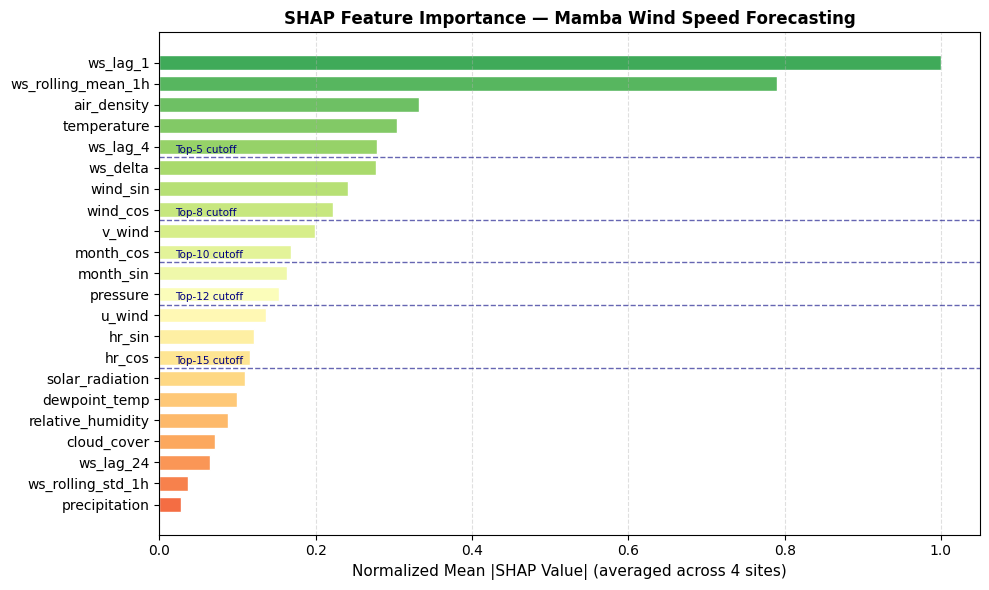

Saved: fig_shap_global_importance.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
colors  = plt.cm.RdYlGn(np.linspace(0.85, 0.2, len(ALL_FEATURES)))

bars = ax.barh(
    df_importance['Feature'][::-1],
    df_importance['Importance_Global'][::-1],
    color=colors[::-1], edgecolor='white', height=0.7
)

for k in [5, 8, 10, 12, 15]:
    ax.axhline(
        len(ALL_FEATURES) - k - 0.5,
        color='navy', linestyle='--', linewidth=1, alpha=0.6
    )
    ax.text(
        df_importance['Importance_Global'].max() * 0.02,
        len(ALL_FEATURES) - k - 0.3,
        f'Top-{k} cutoff', fontsize=7.5, color='navy'
    )

ax.set_xlabel('Normalized Mean |SHAP Value| (averaged across 4 sites)', fontsize=11)
ax.set_title('SHAP Feature Importance — Mamba Wind Speed Forecasting', fontsize=12, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_xlim(left=0)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig_shap_global_importance.png'), dpi=600, bbox_inches='tight')
plt.show()
print('Saved: fig_shap_global_importance.png')

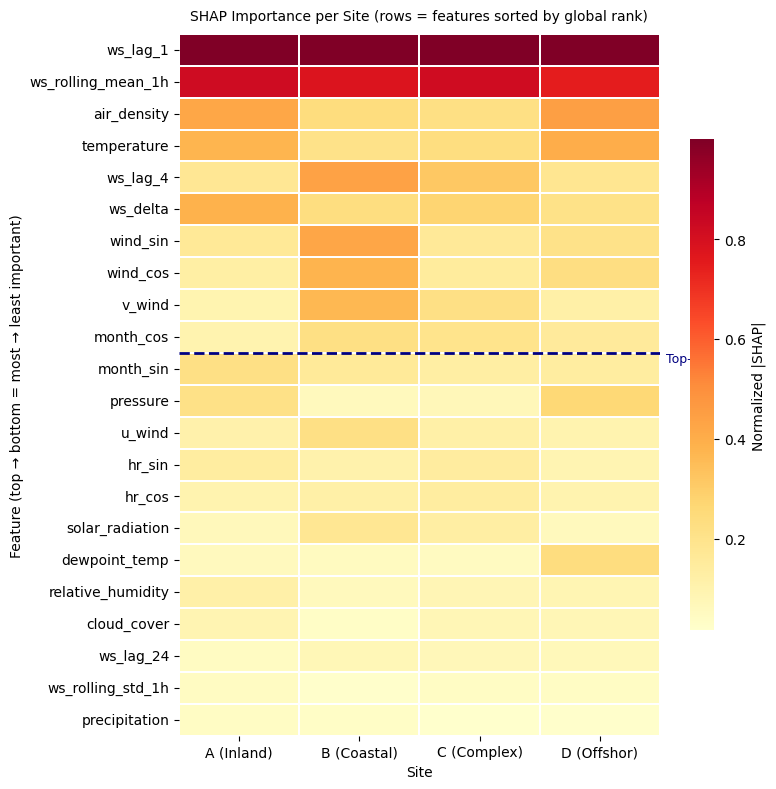

Saved: fig_shap_per_site_heatmap.png


In [ ]:
heatmap_mat = np.column_stack([
    site_shap_scores[s['code']][ranked_global] for s in SITES
])  # (22, 4)

heatmap_norm = heatmap_mat / (heatmap_mat.max(axis=0, keepdims=True) + 1e-9)

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(
    heatmap_norm,
    xticklabels=[f"{s['code']} ({s['name'][:7]})" for s in SITES],
    yticklabels=ranked_features,
    cmap='YlOrRd', ax=ax, linewidths=0.3,
    cbar_kws={'label': 'Normalized |SHAP|', 'shrink': 0.7}
)
ax.set_title('SHAP Importance per Site (rows = features sorted by global rank)',
             fontsize=10, pad=10)
ax.set_xlabel('Site')
ax.set_ylabel('Feature (top → bottom = most → least important)')

# Mark top-10 line
ax.axhline(10, color='navy', linewidth=2, linestyle='--')
ax.text(4.05, 10.3, 'Top-10', color='navy', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig_shap_per_site_heatmap.png'), dpi=600, bbox_inches='tight')
plt.show()
print('Saved: fig_shap_per_site_heatmap.png')

## 6. Phase 2 — Retrain with Top-K Feature Subsets
For each K in [5, 8, 10, 12, 15, 22], retrain Mamba → record accuracy + efficiency.

In [ ]:
_ckpt      = os.path.join(SAVE_DIR, 'phase2_checkpoint.json')
_ckpt_meta = os.path.join(SAVE_DIR, 'phase2_checkpoint_meta.json')

if os.path.exists(_ckpt):
    stale = True  # assume stale until proven otherwise
    if os.path.exists(_ckpt_meta):
        with open(_ckpt_meta) as _f:
            _saved_ranking = json.load(_f).get('ranked_features', [])
        if _saved_ranking == ranked_features:
            stale = False
        else:
            print(f'Ranking changed:')
            print(f'Checkpoint top-5 : {_saved_ranking[:5]}')
            print(f'Current   top-5  : {ranked_features[:5]}')
    else:
        print('Checkpoint has no meta file — treating as stale (old run).')

    if stale:
        os.remove(_ckpt)
        if os.path.exists(_ckpt_meta):
            os.remove(_ckpt_meta)
        print('Stale checkpoint deleted — Phase 2 will run from scratch.')
    else:
        print('Checkpoint ranking matches current — safe to resume.')
else:
    print('No checkpoint found — Phase 2 will start fresh.')

✓  Checkpoint ranking matches current — safe to resume.


In [ ]:
subsets = {k: ranked_features[:k] for k in SUBSET_SIZES}

results = {s['code']: {k: [] for k in SUBSET_SIZES} for s in SITES}

ckpt_path = os.path.join(SAVE_DIR, 'phase2_checkpoint.json')
if os.path.exists(ckpt_path):
    with open(ckpt_path) as f:
        saved = json.load(f)
    for code in saved:
        for k_str, runs in saved[code].items():
            results[code][int(k_str)] = runs
    print(f'Resumed checkpoint: {ckpt_path}')

total_combos = len(SITES) * len(SUBSET_SIZES) * N_SEEDS
combo_done   = sum(
    len(results[s['code']][k]) for s in SITES for k in SUBSET_SIZES
)

for s in SITES:
    code = s['code']
    print(f"\n{'='*60}")
    print(f"  Phase 2 — Site {code} ({s['name']})")
    print(f"{'='*60}")

    for k in SUBSET_SIZES:
        feat_k = subsets[k]

        already_done = len(results[code][k])
        if already_done >= N_SEEDS:
            print(f"  → Top-{k}: already complete ({already_done} runs), skipping.")
            combo_done += already_done
            continue

        print(f"\n  → Top-{k} features: {feat_k}")

        X_tr, y_tr, X_va, y_va, X_te, y_te, scaler_y = load_site(s, feat_k)

        run_results = list(results[code][k])
        for run in range(already_done, N_SEEDS):
            torch.manual_seed(run * 100 + SEED)
            np.random.seed(run * 100 + SEED)

            model = WindMamba(len(feat_k)).to(DEVICE)
            t_tr, tr_hist, va_hist = train_model(model, X_tr, y_tr, X_va, y_va)

            mets, _, _ = evaluate(model, X_te, y_te, scaler_y)
            lat_mean, lat_std = measure_latency(model, X_te)

            run_results.append({
                'n_features'  : k,
                'train_time_s': t_tr,
                'n_epochs'    : len(tr_hist),
                'latency_ms'  : lat_mean,
                'latency_std' : lat_std,
                'metrics'     : mets,
            })

            combo_done += 1
            g_rmse = mets['Global']['RMSE']
            print(f"    Run {run+1}/{N_SEEDS}: RMSE={g_rmse:.4f} | "
                  f"t={t_tr:.0f}s | lat={lat_mean:.3f}ms | "
                  f"epochs={len(tr_hist)}")

            del model
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        results[code][k] = run_results

        with open(ckpt_path, 'w') as f:
            json.dump(results, f)
        with open(_ckpt_meta, 'w') as f:
            json.dump({'ranked_features': ranked_features}, f)
        print(f"Checkpoint saved ({combo_done}/{total_combos} combos done)")

print('\nPhase 2 complete.')


Resumed checkpoint: /content/drive/MyDrive/wind_forecast/SHAP_Optimization/phase2_checkpoint.json

  Phase 2 — Site A (Inland)
  → Top-5: already complete (3 runs), skipping.
  → Top-8: already complete (3 runs), skipping.
  → Top-10: already complete (3 runs), skipping.
  → Top-12: already complete (3 runs), skipping.
  → Top-15: already complete (3 runs), skipping.
  → Top-22: already complete (3 runs), skipping.

  Phase 2 — Site B (Coastal)
  → Top-5: already complete (3 runs), skipping.
  → Top-8: already complete (3 runs), skipping.
  → Top-10: already complete (3 runs), skipping.
  → Top-12: already complete (3 runs), skipping.
  → Top-15: already complete (3 runs), skipping.
  → Top-22: already complete (3 runs), skipping.

  Phase 2 — Site C (Complex Terrain)
  → Top-5: already complete (3 runs), skipping.
  → Top-8: already complete (3 runs), skipping.
  → Top-10: already complete (3 runs), skipping.
  → Top-12: already complete (3 runs), skipping.
  → Top-15: already complet

## 7. Results Aggregation — Paper Tables

In [ ]:
def agg_runs(run_list):
    out = {}
    # Scalar metrics
    for key in ['train_time_s', 'latency_ms', 'n_epochs']:
        vals = [r[key] for r in run_list]
        out[key] = (np.mean(vals), np.std(vals))
    # Horizon metrics
    out['metrics'] = {}
    for hl in HOR_LABELS + ['Global']:
        out['metrics'][hl] = {}
        for met in ['RMSE', 'MAE', 'R2']:
            vals = [r['metrics'][hl][met] for r in run_list]
            out['metrics'][hl][met] = (np.mean(vals), np.std(vals))
    return out


# ── Build flat table ──────────────────────────────────────────────────────────
rows = []
for s in SITES:
    code = s['code']
    # Get baseline (k=22) values for relative change computation
    base_agg = agg_runs(results[code][22])
    base_rmse  = base_agg['metrics']['Global']['RMSE'][0]
    base_time  = base_agg['train_time_s'][0]
    base_lat   = base_agg['latency_ms'][0]

    for k in SUBSET_SIZES:
        agg = agg_runs(results[code][k])
        g   = agg['metrics']['Global']
        rmse_m, rmse_s = g['RMSE']
        mae_m,  mae_s  = g['MAE']
        r2_m,   r2_s   = g['R2']
        t_m, t_s       = agg['train_time_s']
        l_m, l_s       = agg['latency_ms']
        rows.append({
            'Site'           : f"{code} ({s['name']})",
            'N_Features'     : k,
            'Features'       : ', '.join(subsets[k]),
            'RMSE'           : f"{rmse_m:.4f} ± {rmse_s:.4f}",
            'MAE'            : f"{mae_m:.4f} ± {mae_s:.4f}",
            'R2'             : f"{r2_m:.4f} ± {r2_s:.4f}",
            'Train_Time_s'   : f"{t_m:.1f} ± {t_s:.1f}",
            'Latency_ms'     : f"{l_m:.3f} ± {l_s:.3f}",
            'ΔRMSE_vs_full'  : f"{(rmse_m - base_rmse)/base_rmse*100:+.1f}%",
            'ΔTime_vs_full'  : f"{(t_m - base_time)/base_time*100:+.1f}%",
            'ΔLat_vs_full'   : f"{(l_m - base_lat)/base_lat*100:+.1f}%",
            # raw for plots
            '_rmse' : rmse_m, '_t': t_m, '_lat': l_m,
            '_r2'   : r2_m,
        })

df_phase2 = pd.DataFrame(rows)

print('SHAP Feature Optimization Results (Global RMSE):')
print(df_phase2[['Site','N_Features','RMSE','Train_Time_s','Latency_ms',
                  'ΔRMSE_vs_full','ΔTime_vs_full']].to_string(index=False))

df_phase2.to_csv(os.path.join(SAVE_DIR, 'shap_optimization_results.csv'), index=False)
print(f'\nSaved → shap_optimization_results.csv')

SHAP Feature Optimization Results (Global RMSE):
               Site  N_Features            RMSE Train_Time_s    Latency_ms ΔRMSE_vs_full ΔTime_vs_full
         A (Inland)           5 0.5021 ± 0.0044 400.8 ± 14.3 1.016 ± 0.038         +4.2%       +139.2%
         A (Inland)           8 0.4885 ± 0.0089  291.6 ± 5.5 1.029 ± 0.066         +1.4%        +74.1%
         A (Inland)          10 0.5068 ± 0.0116 248.6 ± 15.5 0.998 ± 0.017         +5.2%        +48.4%
         A (Inland)          12 0.4885 ± 0.0030 231.9 ± 43.7 1.069 ± 0.074         +1.4%        +38.4%
         A (Inland)          15 0.4697 ± 0.0027  170.8 ± 9.3 1.090 ± 0.168         -2.5%         +2.0%
         A (Inland)          22 0.4819 ± 0.0116  167.5 ± 6.1 0.988 ± 0.015         +0.0%         +0.0%
        B (Coastal)           5 0.3938 ± 0.0005 434.8 ± 24.6 1.246 ± 0.194         +3.7%       +190.3%
        B (Coastal)           8 0.3916 ± 0.0008 275.8 ± 46.1 1.247 ± 0.195         +3.1%        +84.2%
        B (Coastal)     

## 8. Pareto Frontier & Optimization Figures

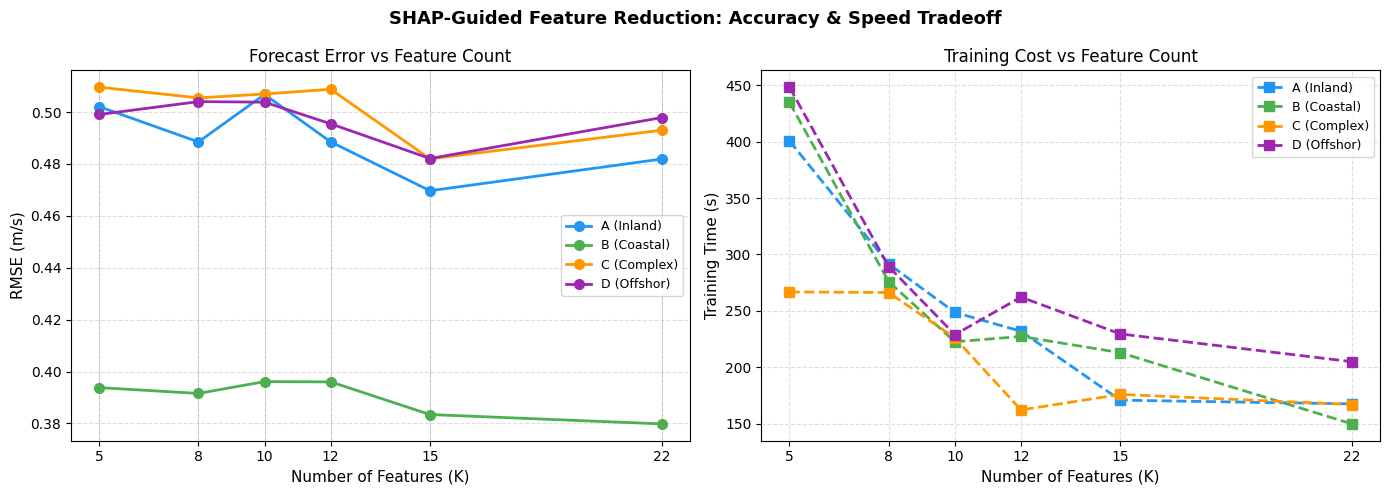

Saved: fig_shap_tradeoff_curves.png


In [ ]:
site_colors = {'A': '#2196F3', 'B': '#4CAF50', 'C': '#FF9800', 'D': '#9C27B0'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SHAP-Guided Feature Reduction: Accuracy & Speed Tradeoff',
             fontsize=13, fontweight='bold')

# Left: RMSE vs K
ax = axes[0]
for s in SITES:
    code  = s['code']
    sub   = df_phase2[df_phase2['Site'].str.startswith(code)]
    ax.plot(sub['N_Features'], sub['_rmse'], 'o-',
            color=site_colors[code], label=f"{code} ({s['name'][:7]})",
            linewidth=2, markersize=7)

for k in SUBSET_SIZES:
    ax.axvline(k, color='gray', linewidth=0.5, linestyle=':')

ax.set_xlabel('Number of Features (K)', fontsize=11)
ax.set_ylabel('RMSE (m/s)', fontsize=11)
ax.set_title('Forecast Error vs Feature Count')
ax.set_xticks(SUBSET_SIZES)
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)

# Right: Training time vs K
ax = axes[1]
for s in SITES:
    code = s['code']
    sub  = df_phase2[df_phase2['Site'].str.startswith(code)]
    ax.plot(sub['N_Features'], sub['_t'], 's--',
            color=site_colors[code], label=f"{code} ({s['name'][:7]})",
            linewidth=2, markersize=7)

ax.set_xlabel('Number of Features (K)', fontsize=11)
ax.set_ylabel('Training Time (s)', fontsize=11)
ax.set_title('Training Cost vs Feature Count')
ax.set_xticks(SUBSET_SIZES)
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig_shap_tradeoff_curves.png'), dpi=200, bbox_inches='tight')
plt.show()
print('Saved: fig_shap_tradeoff_curves.png')

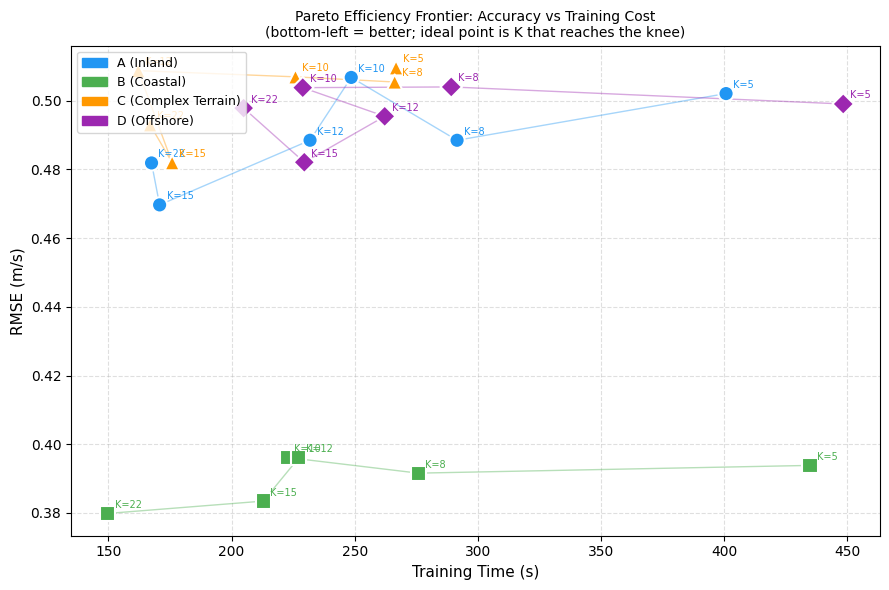

Saved: fig_shap_pareto_frontier.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}

for s in SITES:
    code = s['code']
    sub  = df_phase2[df_phase2['Site'].str.startswith(code)].reset_index()
    sc   = ax.scatter(
        sub['_t'], sub['_rmse'],
        c=[site_colors[code]] * len(sub),
        marker=markers[code], s=120, edgecolors='white', linewidth=1.5,
        zorder=3
    )
    ax.plot(sub['_t'], sub['_rmse'], '-', color=site_colors[code], alpha=0.4, linewidth=1)
    # Label each point with K
    for _, row in sub.iterrows():
        ax.annotate(
            f"K={int(row['N_Features'])}",
            (row['_t'], row['_rmse']),
            textcoords='offset points', xytext=(5, 4), fontsize=7,
            color=site_colors[code]
        )

# Legend
legend_patches = [
    mpatches.Patch(color=site_colors[s['code']], label=f"{s['code']} ({s['name']})")
    for s in SITES
]
ax.legend(handles=legend_patches, fontsize=9, loc='upper left')
ax.set_xlabel('Training Time (s)', fontsize=11)
ax.set_ylabel('RMSE (m/s)', fontsize=11)
ax.set_title('Pareto Efficiency Frontier: Accuracy vs Training Cost\n'
             '(bottom-left = better; ideal point is K that reaches the knee)',
             fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig_shap_pareto_frontier.png'), dpi=200, bbox_inches='tight')
plt.show()
print('Saved: fig_shap_pareto_frontier.png')

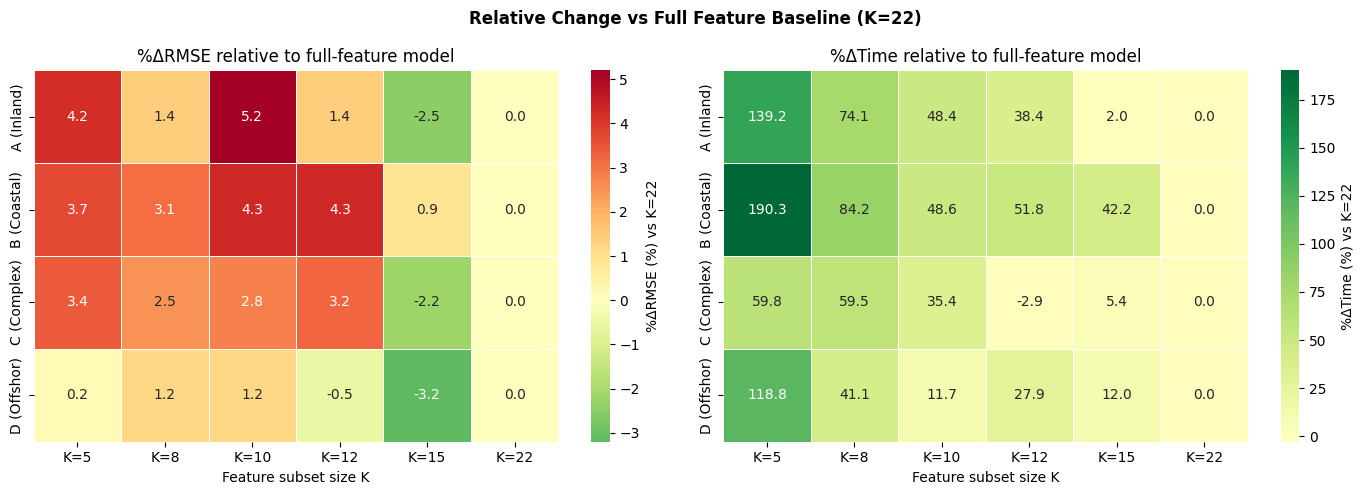

Saved: fig_shap_relative_change_heatmap.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Relative Change vs Full Feature Baseline (K=22)',
             fontsize=12, fontweight='bold')

for ax_i, (metric, col_suffix) in enumerate([('%ΔRMSE', 'ΔRMSE_vs_full'), ('%ΔTime', 'ΔTime_vs_full')]):
    ax = axes[ax_i]

    mat = np.zeros((len(SITES), len(SUBSET_SIZES)))
    for si, s in enumerate(SITES):
        code = s['code']
        sub  = df_phase2[df_phase2['Site'].str.startswith(code)].reset_index(drop=True)
        for ki, k in enumerate(SUBSET_SIZES):
            val_str = sub.loc[sub['N_Features']==k, col_suffix].values[0]
            mat[si, ki] = float(val_str.replace('%',''))

    cmap = 'RdYlGn_r' if 'RMSE' in metric else 'RdYlGn'
    sns.heatmap(
        mat, annot=True, fmt='.1f', cmap=cmap,
        xticklabels=[f'K={k}' for k in SUBSET_SIZES],
        yticklabels=[f"{s['code']} ({s['name'][:7]})" for s in SITES],
        ax=ax, linewidths=0.5, center=0,
        cbar_kws={'label': f'{metric} (%) vs K=22'}
    )
    ax.set_title(f'{metric} relative to full-feature model')
    ax.set_xlabel('Feature subset size K')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig_shap_relative_change_heatmap.png'), dpi=200, bbox_inches='tight')
plt.show()
print('Saved: fig_shap_relative_change_heatmap.png')

## 9. Optimal K Selection — Knee Detection

In [ ]:
RMSE_TOLERANCE = 0.02  # accept ≤ 2% RMSE increase vs full model
TIME_SAVING    = 0.10  # want ≥ 10% time saving

print('=== Optimal K Selection per Site ===')
print(f'Criteria: ΔRMSE ≤ +{RMSE_TOLERANCE*100:.0f}%  AND  ΔTime ≤ -{TIME_SAVING*100:.0f}%')
print()

optimal_k = {}
for s in SITES:
    code = s['code']
    sub  = df_phase2[df_phase2['Site'].str.startswith(code)].sort_values('N_Features')

    base_rmse = sub.loc[sub['N_Features']==22, '_rmse'].values[0]
    base_time = sub.loc[sub['N_Features']==22, '_t'].values[0]

    chosen = 22
    for _, row in sub.iterrows():
        k      = int(row['N_Features'])
        d_rmse = (row['_rmse'] - base_rmse) / base_rmse
        d_time = (row['_t']   - base_time) / base_time
        if d_rmse <= RMSE_TOLERANCE and d_time <= -TIME_SAVING:
            chosen = k
            break  # take smallest K that meets criteria

    optimal_k[code] = chosen
    chosen_row = sub.loc[sub['N_Features']==chosen].iloc[0]
    print(f"  Site {code} ({s['name']}): Optimal K = {chosen}")
    print(f"    RMSE     : {chosen_row['RMSE']}")
    print(f"    Train t  : {chosen_row['Train_Time_s']}")
    print(f"    ΔRMSE    : {chosen_row['ΔRMSE_vs_full']}  |  ΔTime: {chosen_row['ΔTime_vs_full']}")
    print(f"    Features : {subsets[chosen]}")
    print()

print(f'Global optimal K recommendation: {pd.Series(optimal_k).mode()[0]}')

=== Optimal K Selection per Site ===
Criteria: ΔRMSE ≤ +2%  AND  ΔTime ≤ -10%

  Site A (Inland): Optimal K = 22
    RMSE     : 0.4819 ± 0.0116
    Train t  : 167.5 ± 6.1
    ΔRMSE    : +0.0%  |  ΔTime: +0.0%
    Features : ['ws_lag_1', 'ws_rolling_mean_1h', 'air_density', 'temperature', 'ws_lag_4', 'ws_delta', 'wind_sin', 'wind_cos', 'v_wind', 'month_cos', 'month_sin', 'pressure', 'u_wind', 'hr_sin', 'hr_cos', 'solar_radiation', 'dewpoint_temp', 'relative_humidity', 'cloud_cover', 'ws_lag_24', 'ws_rolling_std_1h', 'precipitation']

  Site B (Coastal): Optimal K = 22
    RMSE     : 0.3798 ± 0.0030
    Train t  : 149.7 ± 22.1
    ΔRMSE    : +0.0%  |  ΔTime: +0.0%
    Features : ['ws_lag_1', 'ws_rolling_mean_1h', 'air_density', 'temperature', 'ws_lag_4', 'ws_delta', 'wind_sin', 'wind_cos', 'v_wind', 'month_cos', 'month_sin', 'pressure', 'u_wind', 'hr_sin', 'hr_cos', 'solar_radiation', 'dewpoint_temp', 'relative_humidity', 'cloud_cover', 'ws_lag_24', 'ws_rolling_std_1h', 'precipitation']


## 11. Key Numbers for Paper Narrative

In [ ]:
print('=== NARRATIVE NUMBERS — Copy into Section 3.1 / 3.3 ===')
print()

# Average savings at optimal K
rmse_changes, time_changes, lat_changes = [], [], []
for s in SITES:
    code = s['code']
    k    = optimal_k[code]
    row  = df_phase2[
        (df_phase2['Site'].str.startswith(code)) &
        (df_phase2['N_Features'] == k)
    ].iloc[0]
    rmse_changes.append(float(row['ΔRMSE_vs_full'].replace('%','')))
    time_changes.append(float(row['ΔTime_vs_full'].replace('%','')))
    lat_changes.append(float(row['ΔLat_vs_full'].replace('%','')))

print(f'[1] Most important feature globally: {ranked_features[0]}')
print(f'[2] Top-5 features: {ranked_features[:5]}')
print(f'[3] Top-10 features: {ranked_features[:10]}')
print()
print(f'[4] Optimal K per site: {optimal_k}')
print(f'[5] At optimal K:')
print(f'    Avg ΔRMSE vs full model : {np.mean(rmse_changes):+.2f}%  (± {np.std(rmse_changes):.2f}%)')
print(f'    Avg ΔTrain time         : {np.mean(time_changes):+.1f}%  (± {np.std(time_changes):.1f}%)')
print(f'    Avg ΔLatency            : {np.mean(lat_changes):+.1f}%  (± {np.std(lat_changes):.1f}%)')
print()

# Agreement across sites for top features
top5_per_site = [
    set(ALL_FEATURES[j]
        for j in np.argsort(site_shap_scores[s['code']])[::-1][:5])
    for s in SITES
]
print(f'[6] Top-5 global features (cross-site agreement):')
for i, feat in enumerate(ranked_features[:5]):
    n_sites_top5 = sum(
        feat in [ALL_FEATURES[j] for j in
                 np.argsort(site_shap_scores[s['code']])[::-1][:5]]
        for s in SITES
    )
    print(f'    {i+1}. {feat:30s} — top-5 in {n_sites_top5}/4 sites')

print()
print('Sample sentence for paper:')
print(f'"SHAP analysis identifies {ranked_features[0]}, {ranked_features[1]}, and')
print(f'{ranked_features[2]} as the three most influential predictors across all wind')
print(f'regimes. Retraining Mamba with the SHAP-optimal Top-{pd.Series(optimal_k).mode()[0]}')
print(f'feature subset achieves {np.mean(rmse_changes):+.1f}% ΔRMSE while reducing training')
print(f'time by {abs(np.mean(time_changes)):.1f}%, demonstrating that XAI-guided feature')
print(f'selection enables efficient deployment without sacrificing predictive accuracy."')

=== NARRATIVE NUMBERS — Copy into Section 3.1 / 3.3 ===

[1] Most important feature globally: ws_lag_1
[2] Top-5 features: ['ws_lag_1', 'ws_rolling_mean_1h', 'air_density', 'temperature', 'ws_lag_4']
[3] Top-10 features: ['ws_lag_1', 'ws_rolling_mean_1h', 'air_density', 'temperature', 'ws_lag_4', 'ws_delta', 'wind_sin', 'wind_cos', 'v_wind', 'month_cos']

[4] Optimal K per site: {'A': 22, 'B': 22, 'C': 22, 'D': 22}
[5] At optimal K:
    Avg ΔRMSE vs full model : +0.00%  (± 0.00%)
    Avg ΔTrain time         : +0.0%  (± 0.0%)
    Avg ΔLatency            : +0.0%  (± 0.0%)

[6] Top-5 global features (cross-site agreement):
    1. ws_lag_1                       — top-5 in 4/4 sites
    2. ws_rolling_mean_1h             — top-5 in 4/4 sites
    3. air_density                    — top-5 in 2/4 sites
    4. temperature                    — top-5 in 3/4 sites
    5. ws_lag_4                       — top-5 in 2/4 sites

Sample sentence for paper:
"SHAP analysis identifies ws_lag_1, ws_rolling_me